# Adaptive Polymorphic Mode Decomposition (APMD)

This notebook introduces **Adaptive Polymorphic Mode Decomposition (APMD)** and provides executable examples with PySDKit.

APMD is designed for **polymorphic** multi-component signals—mixtures that may contain both **frequency-dominant** modes (AM–FM / chirps) and **time-dominant** modes (impacts, dispersive waves). It works on the time–frequency plane rather than a fixed parametric basis.

**Reference**

> Z. Huang, J. Liu.  
> *Adaptive Polymorphic Mode Decomposition.*  
> Digital Signal Processing, 161:104913, 2025.  
> [DOI: 10.1016/j.dsp.2024.104913](https://doi.org/10.1016/j.dsp.2024.104913)

Huang Z. and Liu J., Digital Signal Processing, 161:104913, 2025.

## 1. Why APMD?

Classical mode-decomposition tools are often specialized:

- **EMD-like** methods are fully data-driven but can mix modes under noise.
- **VMD / VNCMD / ACMD-like** methods assume slowly varying AM–FM bases and struggle with strong impacts or dispersive (frequency-dependent) energy.
- **SST / SET-like** post-processors refine a TFR, but separating mixed polymorphic ridges still needs careful ridge tracking and bandwidth control.

**APMD** combines ideas from variational mode decomposition and synchro-squeezing:

1. Build a TFR with an **adaptively chosen STFT window**.
2. Detect whether the dominant energy ridge is **frequency-dominant** (`voh=0`) or **time-dominant** (`voh=1`).
3. Jointly optimize **ridge + upper/lower bandwidths**.
4. Restore the mode by integrating the TFR inside the bandwidth, then **squeeze** energy onto the ridge.

No predefined chirplet / GDM basis is required—the algorithm adapts mode geometry from the TFR itself.

## 2. Core formulas

### 2.1 STFT and mode reconstruction

For a discrete signal $x(t)$, the windowed STFT is

$$
X(t,f)=\sum_k x(k)\,w(t-k)\,e^{-j2\pi f k}.
$$

Within a local frequency (or time) support around a ridge, the mode can be restored by integrating the TFR (SST-style reconstruction), e.g. for a frequency-dominant mode

$$
x_m(t)=\mathrm{Re}\left\{\frac{2}{w_0}\int_{f\in\mathcal B(t)} X(t,f)\,\mathrm df\right\},
$$

where $\mathcal B(t)=[\tilde f(t)-v(t),\,\tilde f(t)+u(t)]$ is the optimized bandwidth and $w_0$ normalizes the analysis window.

### 2.2 Adaptive window length

Before each extraction, APMD selects a window length by minimizing a **Rényi entropy** concentration measure of an adaptive B-spline STFT (Liu–Riemenschneider–Shen). A more concentrated TFR yields a smaller entropy and a better matched window for the current residual.

### 2.3 Ridge type: frequency- vs time-dominant

From the TFR magnitude, APMD tracks candidate ridges along time (IF) and along frequency (group delay / IT). Comparing ridge energies decides the mode form:

- `voh = 0`: **frequency-dominant** (IF ridge; typical AM–FM / chirp)
- `voh = 1`: **time-dominant** (IT ridge; typical impact / dispersive energy)

### 2.4 Bandwidth / ridge iteration

Given an initial half-bandwidth $D$, APMD alternately:

1. optimizes upper/lower bandwidths $(u,v)$ by a local cost balancing bandwidth size and reconstruction residual;
2. re-estimates the ridge as an energy-weighted centroid inside the bandwidth;
3. stops when the mode update is small or the control cost no longer decreases.

### 2.5 Outer separation loop

Extracted modes are subtracted from the residual until

$$
\frac{\|x-\sum_k x_k\|_2^2}{\|x\|_2^2}<\mathrm{thd}
$$

or the maximum number of modes is reached. The last component stores the residual.

## 3. Algorithm sketch

```text
Input:  x(t), fs, Nmode, D, thd, thd2
Output: modes, squeezed TFR, IF/IT ridges, bandwidths, voh flags

x_iter <- x
for k = 1, 2, ..., Nmode-1 while residual energy > thd:
    wl <- optwin(x_iter)                 # adaptive STFT window
    X  <- STFT(x_iter; wl)
    (xm, IF, IT, u, v, voh) <- single_mod_ext(x_iter, X, ...)
    store mode k; x_iter <- x_iter - xm
residual <- x - sum of extracted modes
squeeze each non-residual mode onto its ridge -> X_s
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if (ROOT / "pysdkit").is_dir() and str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "pysdkit").is_dir() and str(ROOT.parent) not in sys.path:
    sys.path.insert(0, str(ROOT.parent))

from pysdkit import APMD
from pysdkit.plot import plot_IMFs, plot_signal

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(APMD())

Adaptive Polymorphic Mode Decomposition (APMD)


## 4. Build a demo signal

We use a shortened mixture inspired by the paper demos: one amplitude-modulated tone and one nonlinear chirp, plus light noise.  
(Full MATLAB demos use $f_s=5000$ Hz and are much heavier; this notebook keeps $N$ modest so it runs quickly.)

N=250, fs=500.0 Hz


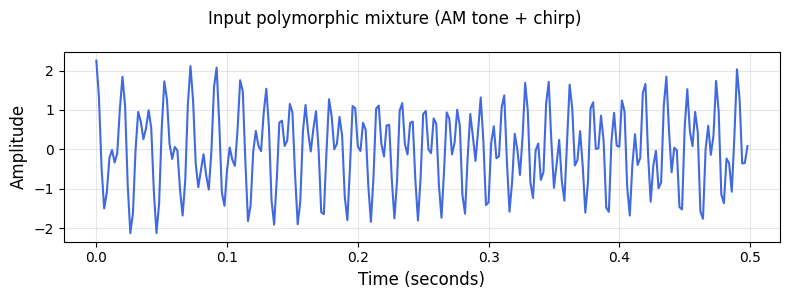

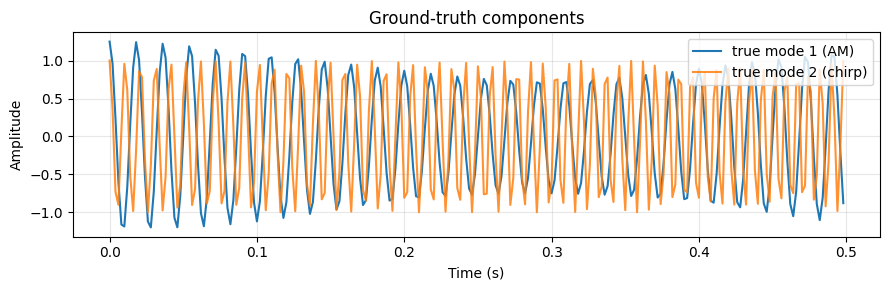

In [2]:
def make_demo_signal(fs: float = 500.0, T: float = 0.5, seed: int = 0):
    rng = np.random.default_rng(seed)
    t = np.arange(0.0, T, 1.0 / fs)
    x1 = (1.0 + 0.25 * np.cos(2 * np.pi * 1.7 * t)) * np.cos(2 * np.pi * 55.0 * t)
    x2 = np.cos(2 * np.pi * (95.0 * t + 35.0 * t**2))
    signal = x1 + x2 + 0.03 * rng.standard_normal(t.size)
    return t, signal, x1, x2


fs = 500.0
t, signal, x1, x2 = make_demo_signal(fs=fs)
print(f"N={signal.size}, fs={fs} Hz")

fig = plot_signal(t, signal)
fig.suptitle("Input polymorphic mixture (AM tone + chirp)", fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, x1, label="true mode 1 (AM)")
ax.plot(t, x2, label="true mode 2 (chirp)", alpha=0.85)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Ground-truth components")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 5. Run APMD

| Parameter | Role |
|-----------|------|
| `n_modes` | Maximum modes including residual |
| `d` | Initial half bandwidth (TFR bins); default $\approx 0.02N$ |
| `thd` | Outer residual-energy stop |
| `thd2` | Inner mode-update stop |
| `fs` | Sampling frequency |

In [3]:
apmd = APMD(n_modes=5, d=10, thd=0.05, thd2=0.05, max_inner_iter=5)
result = apmd.fit_transform(signal, fs=fs, return_all=True)

modes = result["modes"]
print(f"modes:     {modes.shape}")
print(f"wl_opt:    {result['wl_opt']}")
print(f"voh:       {result['voh']}   (0=freq-dominant, 1=time-dominant)")
print(f"elapsed:   {result['elapsed']:.3f} s")

recon_re = np.linalg.norm(modes.sum(0) - signal) / np.linalg.norm(signal)
print(f"reconstruction RE (with residual): {recon_re:.3e}")

cands = modes[:-1] if modes.shape[0] > 1 else modes


def best_re(ref):
    return min(np.linalg.norm(c - ref) / np.linalg.norm(ref) for c in cands)


print(f"best RE vs true AM mode:   {best_re(x1):.4f}")
print(f"best RE vs true chirp mode:{best_re(x2):.4f}")

modes:     (5, 250)
wl_opt:    [ 80.  80.  80.  80. 160.]
voh:       [0. 0. 0. 0. 0.]   (0=freq-dominant, 1=time-dominant)
elapsed:   0.321 s
reconstruction RE (with residual): 1.146e-18
best RE vs true AM mode:   0.2837
best RE vs true chirp mode:0.3067


## 6. Visualize modes and squeezed TFR

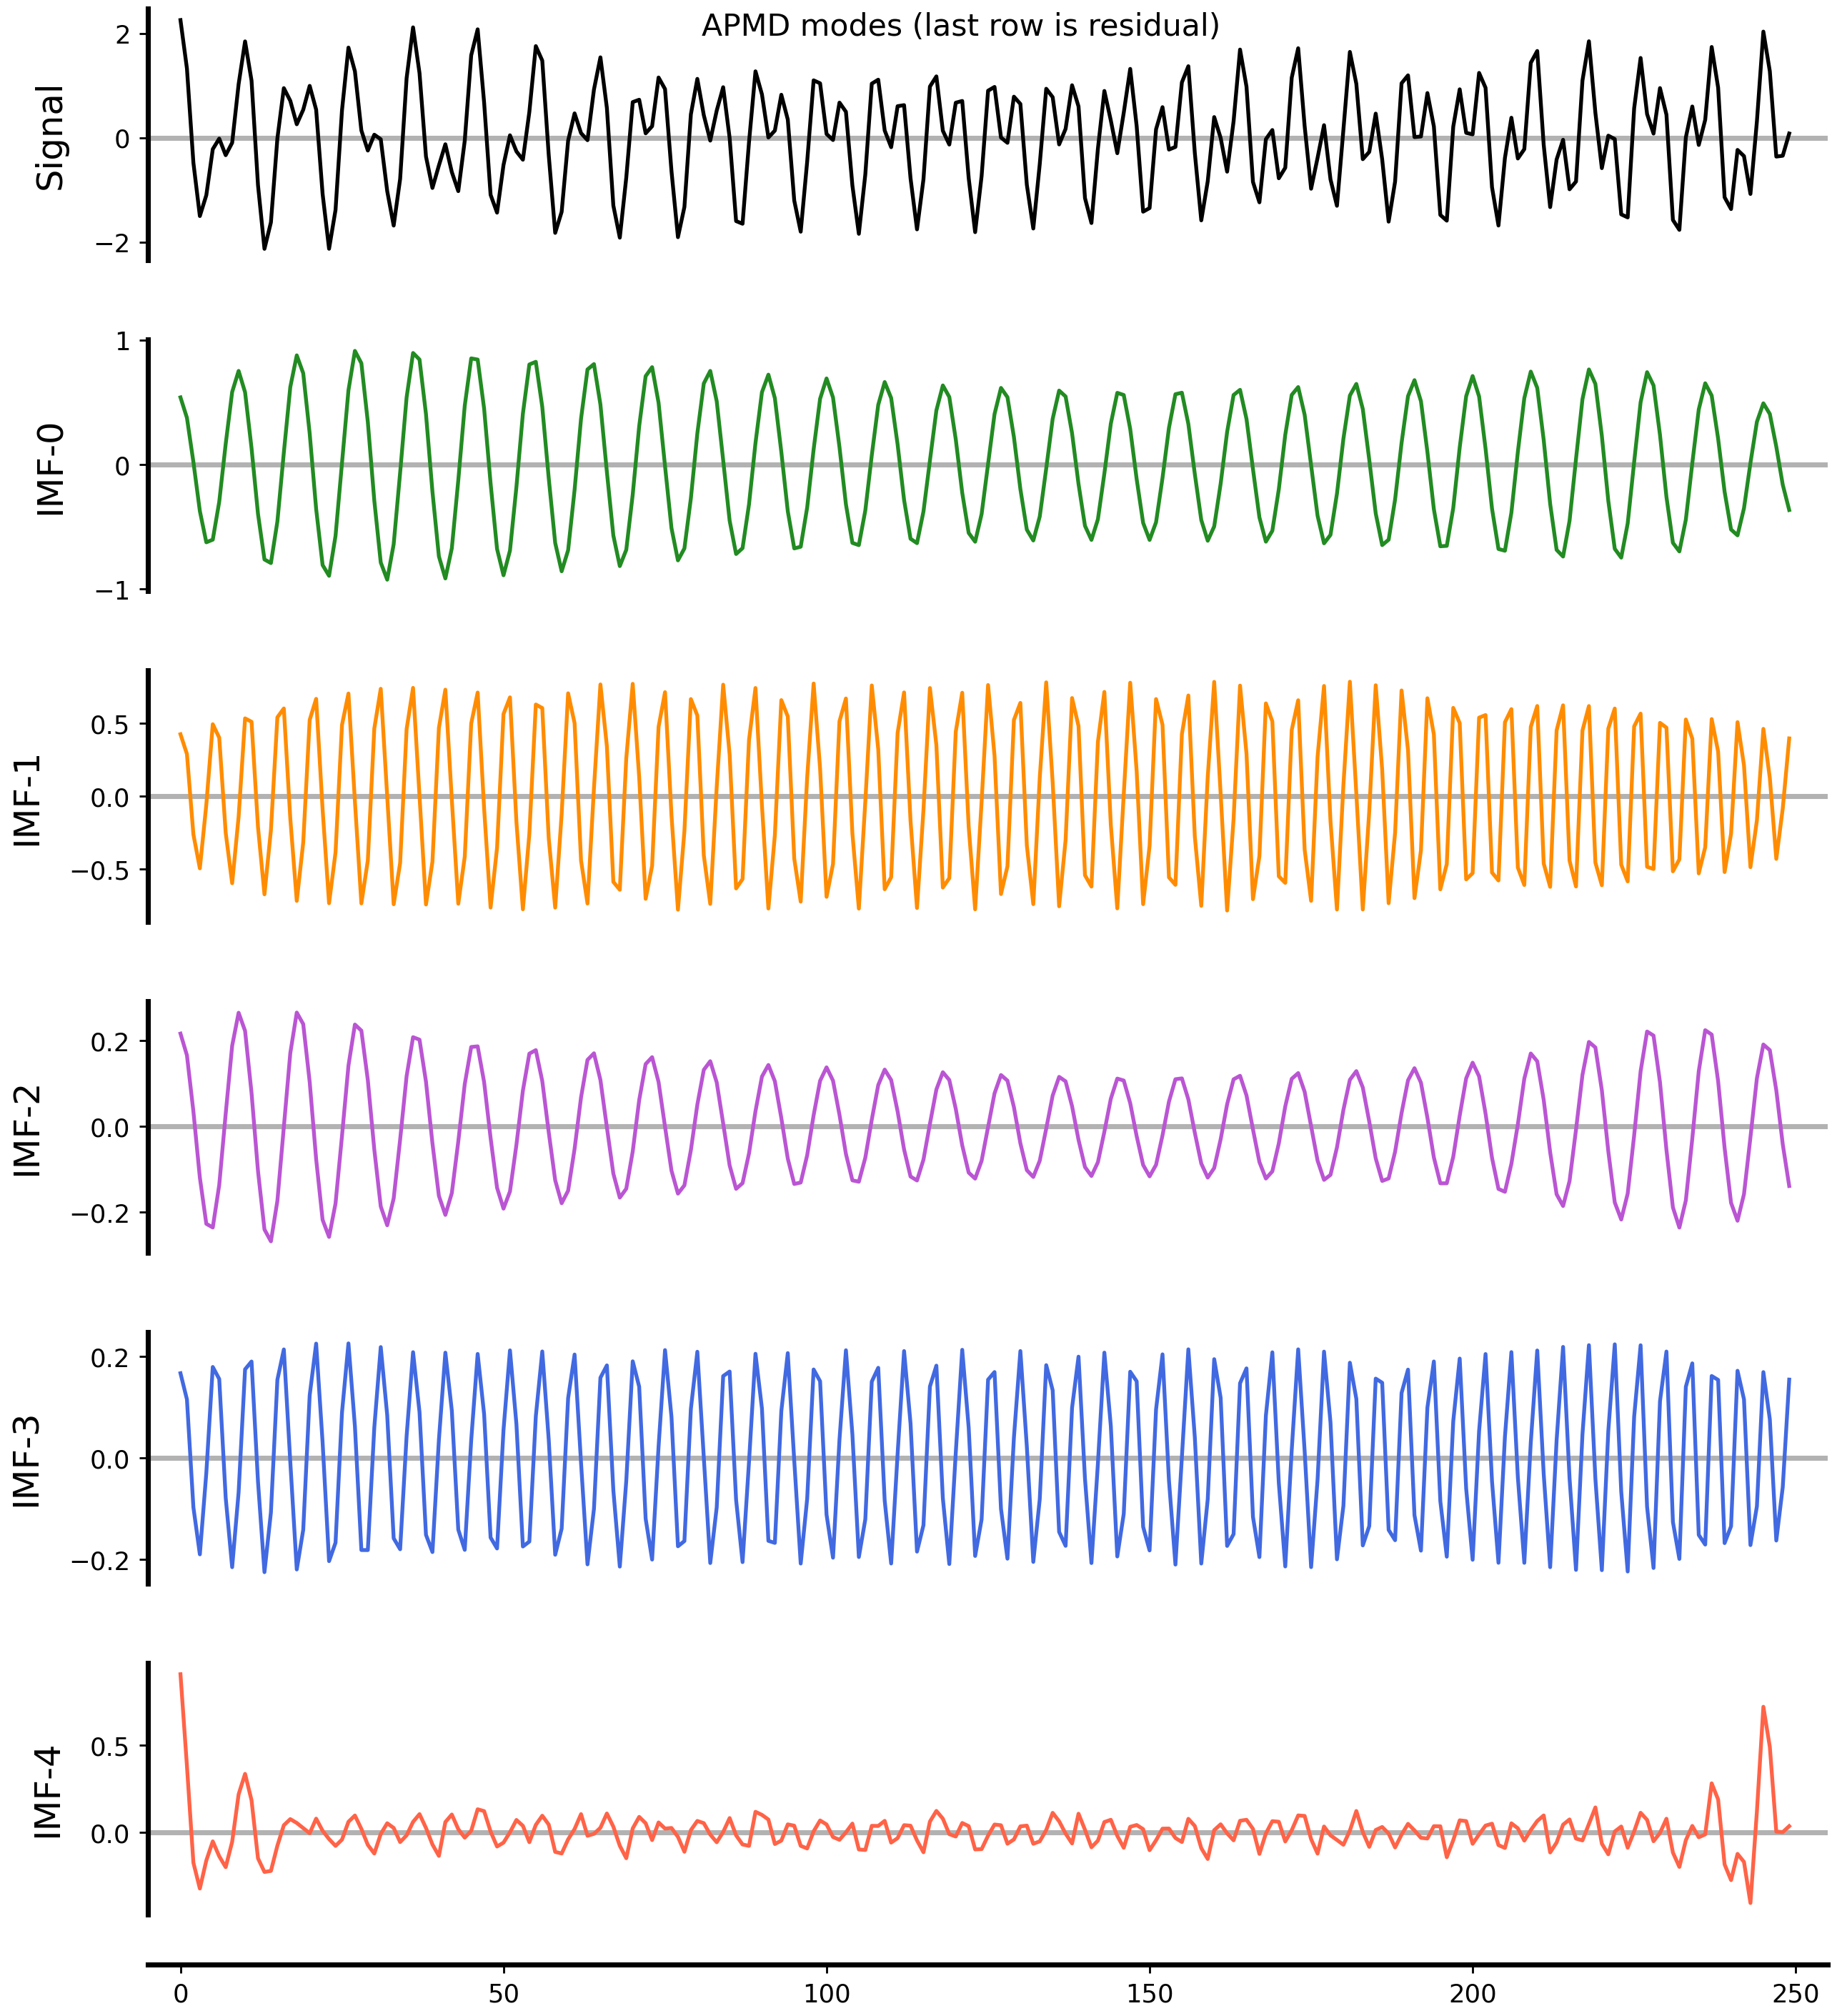

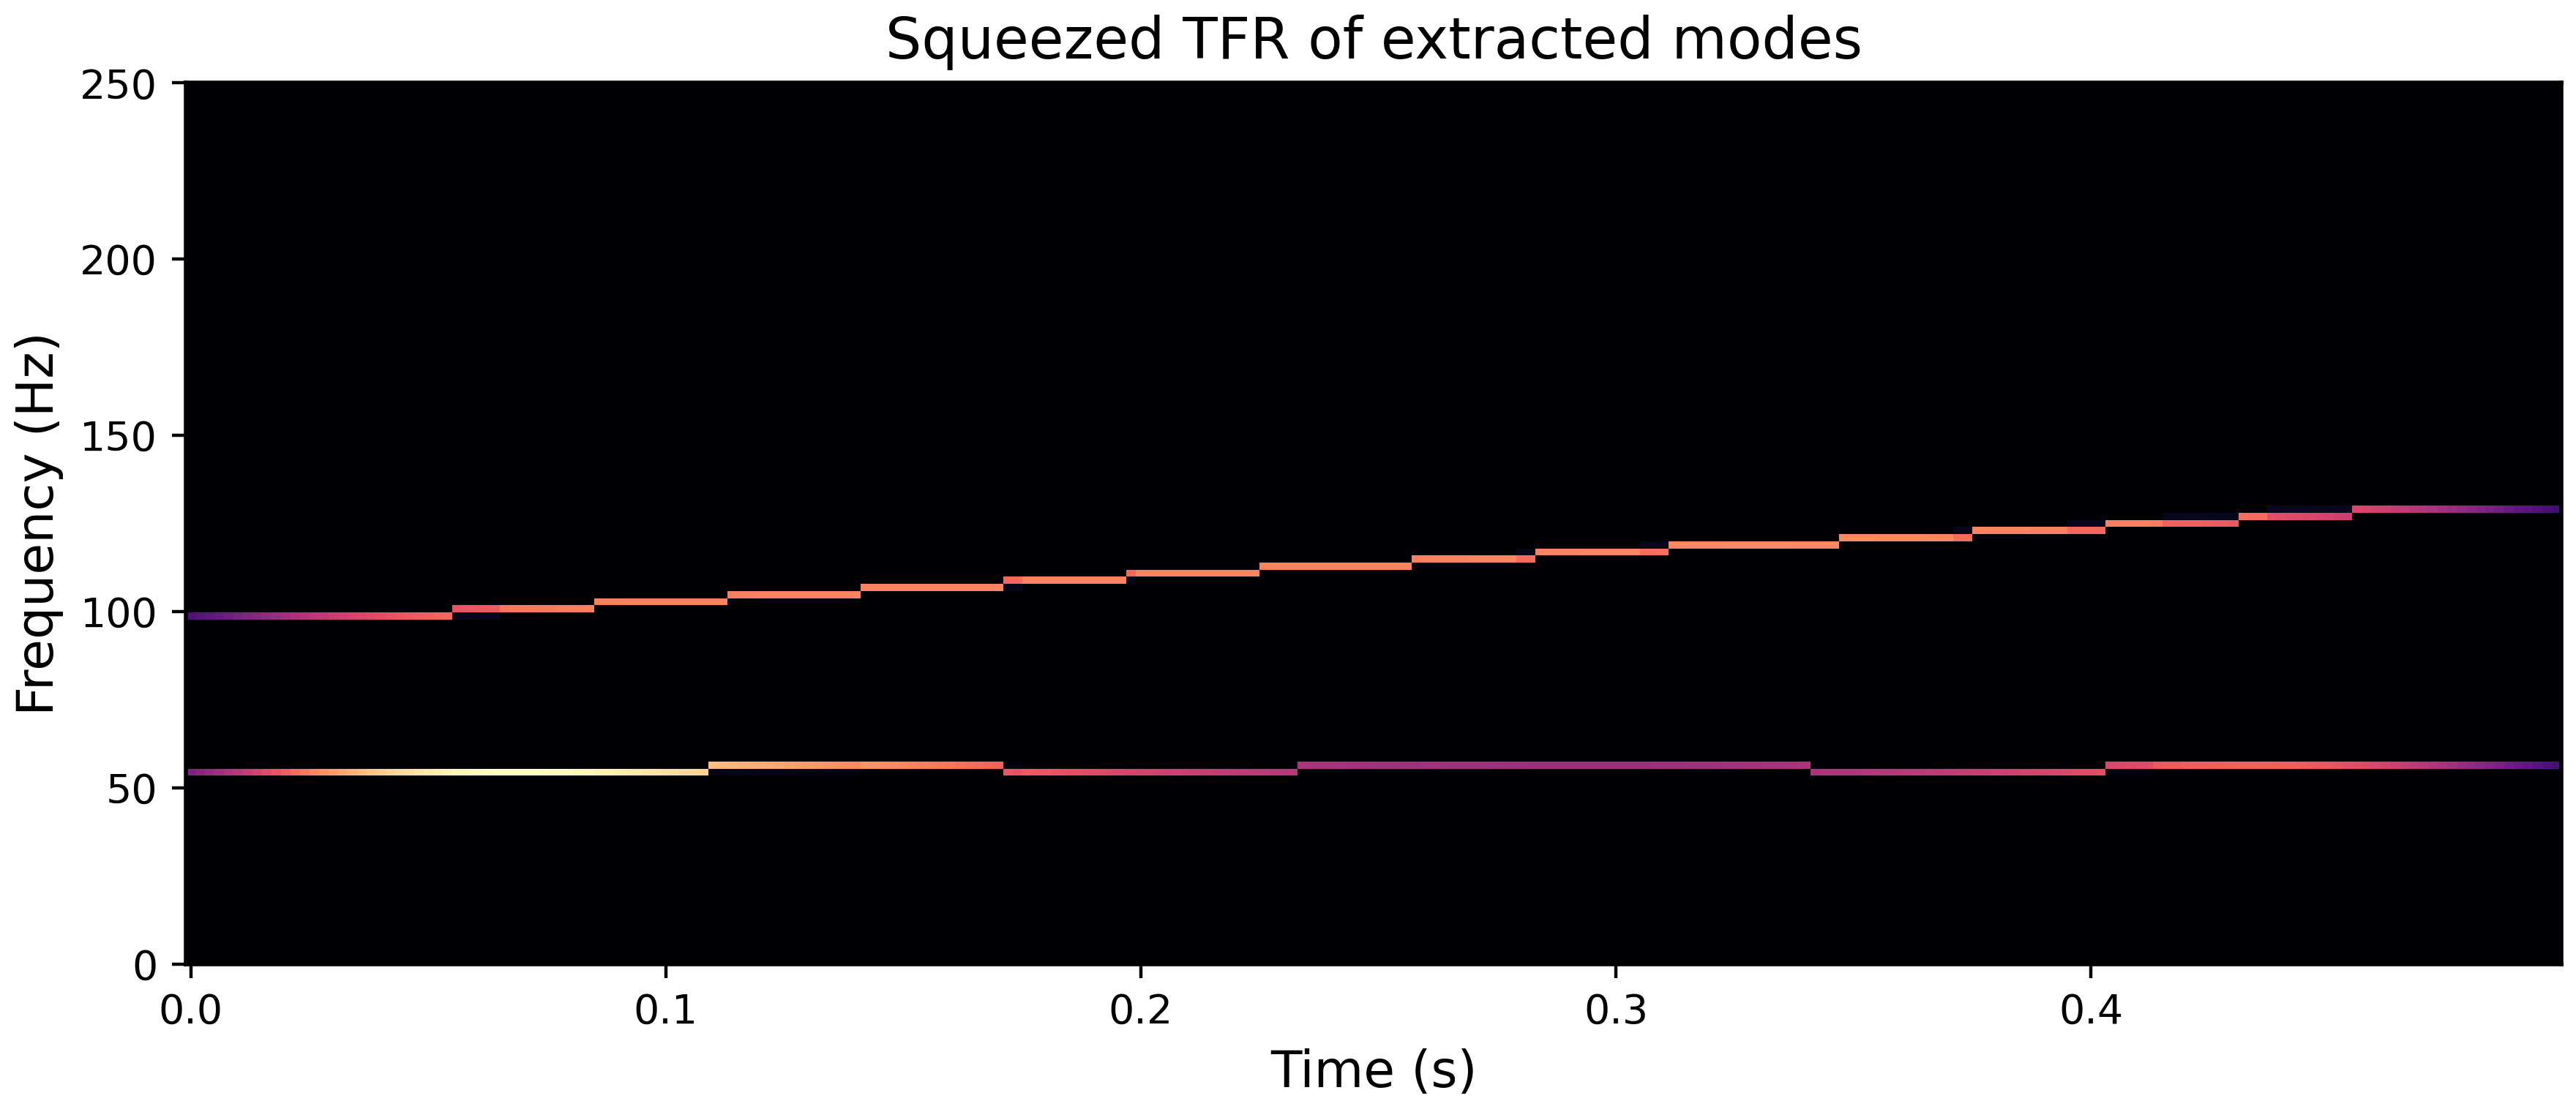

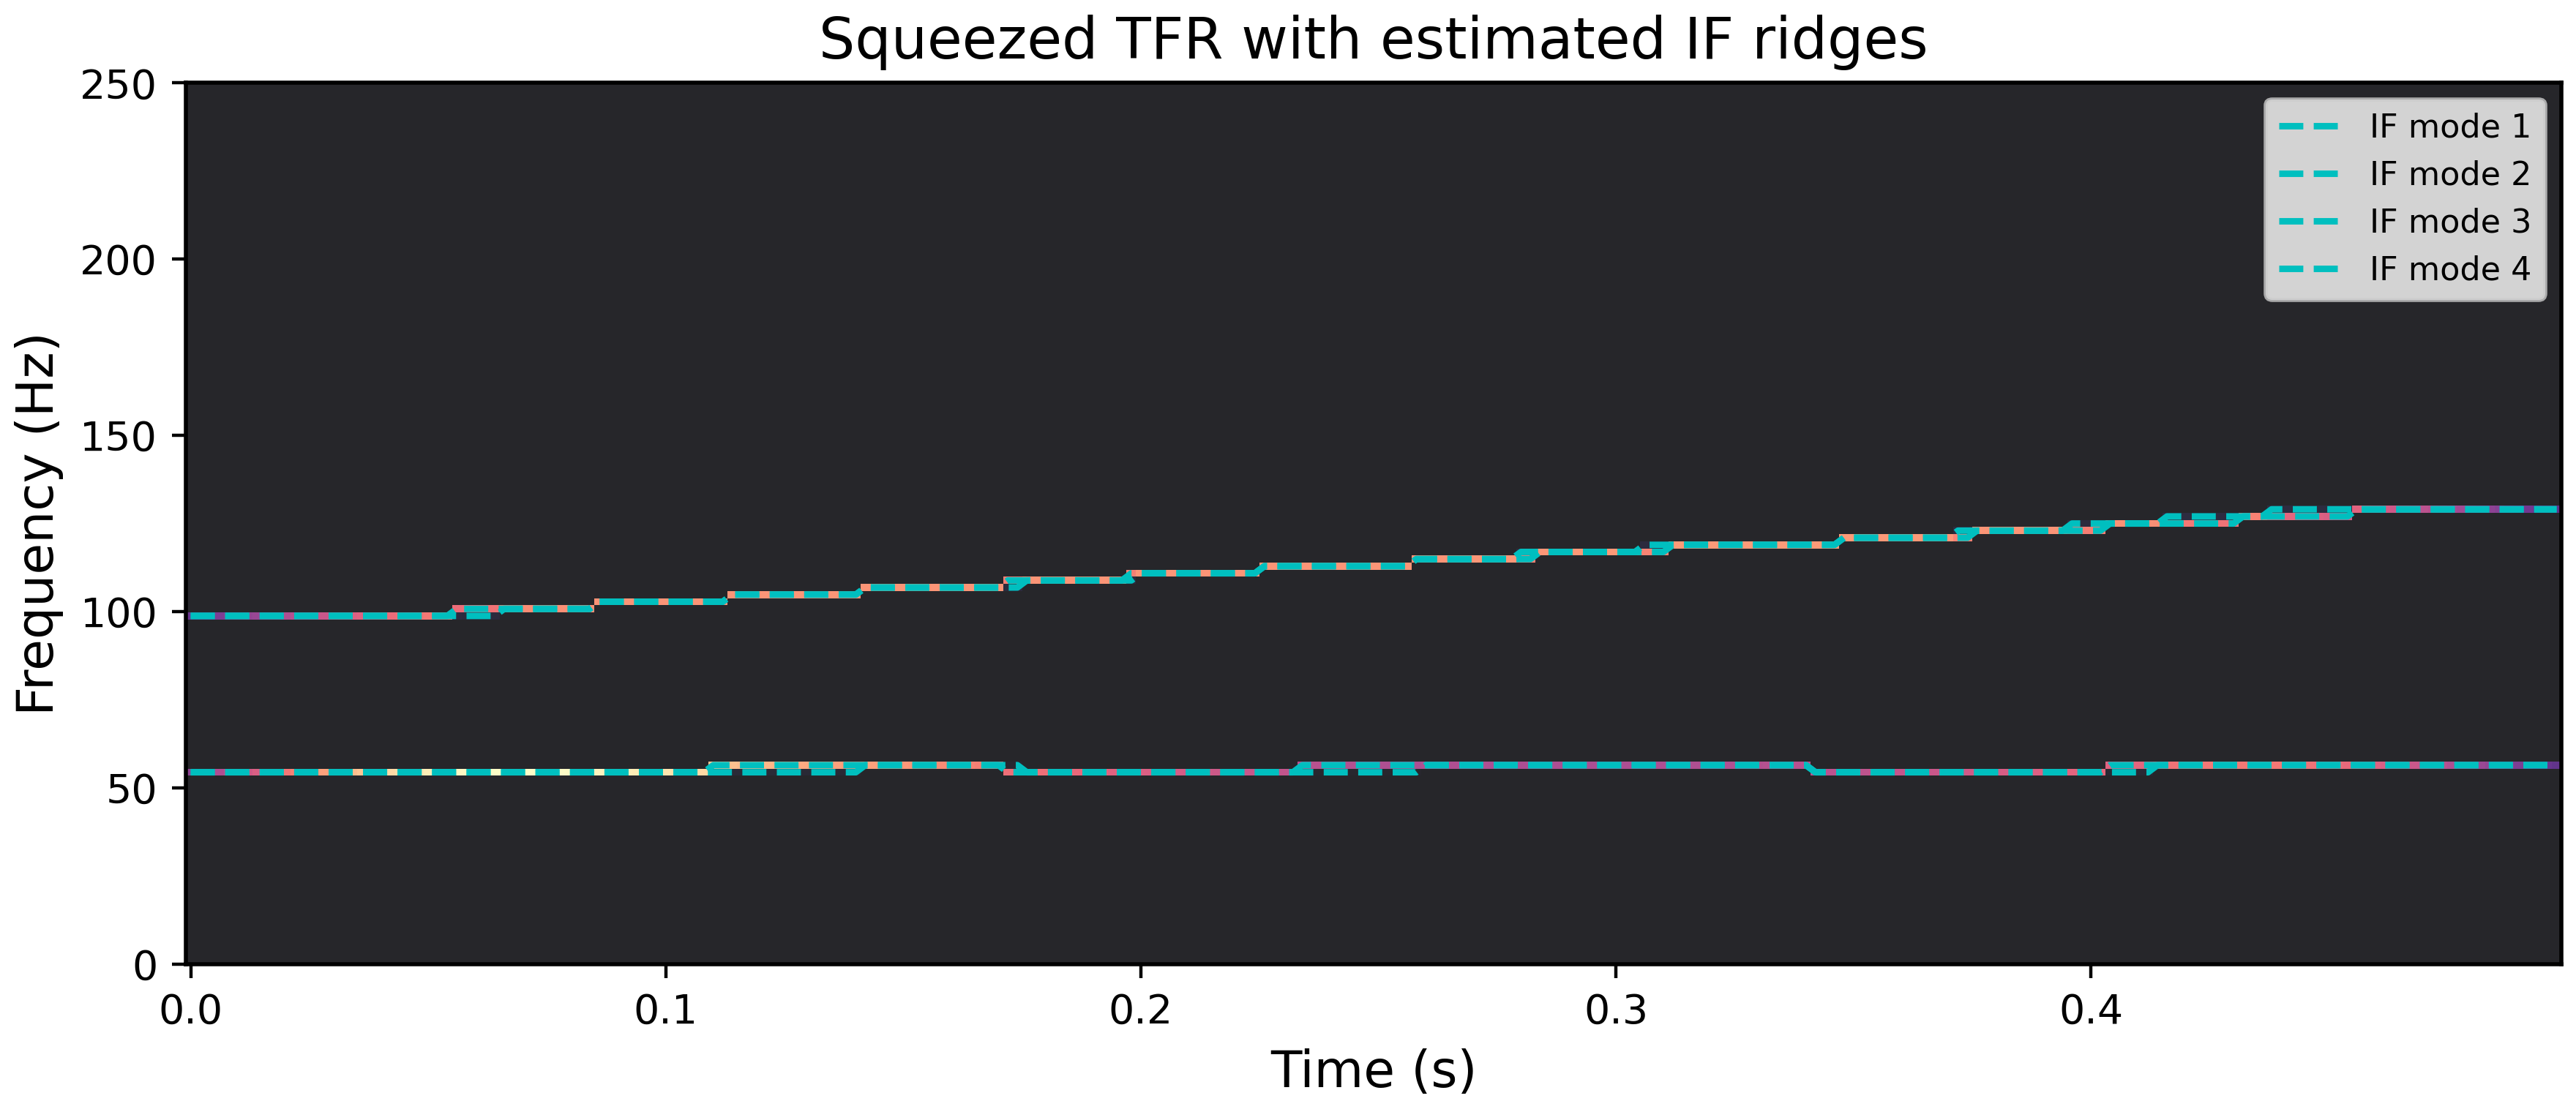

In [4]:
plot_IMFs(signal, modes)
plt.suptitle("APMD modes (last row is residual)", fontsize=12)
plt.show()

X_s = result["tfr_squeezed"]
f_axis = np.linspace(0.0, fs / 2.0, X_s.shape[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.pcolormesh(t, f_axis, np.abs(X_s), shading="auto", cmap="magma")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Squeezed TFR of extracted modes")
ax.set_ylim(0, fs / 2)
plt.tight_layout()
plt.show()

# Overlay IF ridges for frequency-dominant modes
fig, ax = plt.subplots(figsize=(9, 4))
ax.pcolormesh(t, f_axis, np.abs(X_s), shading="auto", cmap="magma", alpha=0.85)
df = f_axis[1] - f_axis[0] if f_axis.size > 1 else 1.0
for k, flag in enumerate(result["voh"][:-1]):
    if int(flag) == 0:
        # IF stored as frequency-bin indices
        if_hz = result["if_mode"][k] * df
        ax.plot(t, if_hz, "c--", lw=1.6, label=f"IF mode {k+1}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Squeezed TFR with estimated IF ridges")
ax.set_ylim(0, fs / 2)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Takeaways

- APMD is a **TFR-driven** decomposition framework for polymorphic mixtures.
- Each step adapts the **STFT window**, decides **mode geometry** (`voh`), and jointly refines **ridge + bandwidth**.
- Modes are restored by **band-limited TFR integration** and visualized via **ridge squeezing**.
- In PySDKit: `from pysdkit import APMD`, then `modes = APMD(...).fit_transform(signal, fs=...)`.
  Use `return_all=True` for squeezed TFRs, ridges, bandwidths, and `voh`.

**Further reading**

- Huang & Liu, *Adaptive Polymorphic Mode Decomposition*, DSP 2025.
- Related ideas: VMD / ACMD (variational AM–FM), SST / TSST (reassignment), GDMD (dispersive modes).